1.LOAD DATASET

In [1]:
import pandas as pd

PLATFORM = "Instagram"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/instagram_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(24156, 58)
(6039, 58)


In [2]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [3]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

model = XGBClassifier(

    # objective
    objective="binary:logistic",

    # evaluation metric
    eval_metric="logloss",

    # tree settings
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,

    # randomness
    random_state=42,

    # parallel processing
    n_jobs=-1
)

In [4]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


In [6]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [7]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred
    )
)
print(f"ROC-AUC  : {roc_auc:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4828
           1       0.67      0.43      0.53      1211

    accuracy                           0.84      6039
   macro avg       0.77      0.69      0.72      6039
weighted avg       0.83      0.84      0.83      6039

ROC-AUC  : 0.8666


In [8]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[4575  253]
 [ 688  523]]


In [9]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.312868
5              verified    0.027136
33         topic_Sports    0.019442
22       topic_Business    0.019083
30         topic_Health    0.017879
41    language_Japanese    0.017680
54     location_Unknown    0.017678
25  topic_Entertainment    0.017512
45      media_type_Link    0.017231
43  language_Portuguese    0.016895
39      language_German    0.016857
32        topic_Science    0.015777
28           topic_Food    0.015743
8    sentiment_positive    0.015720
31       topic_Politics    0.015519


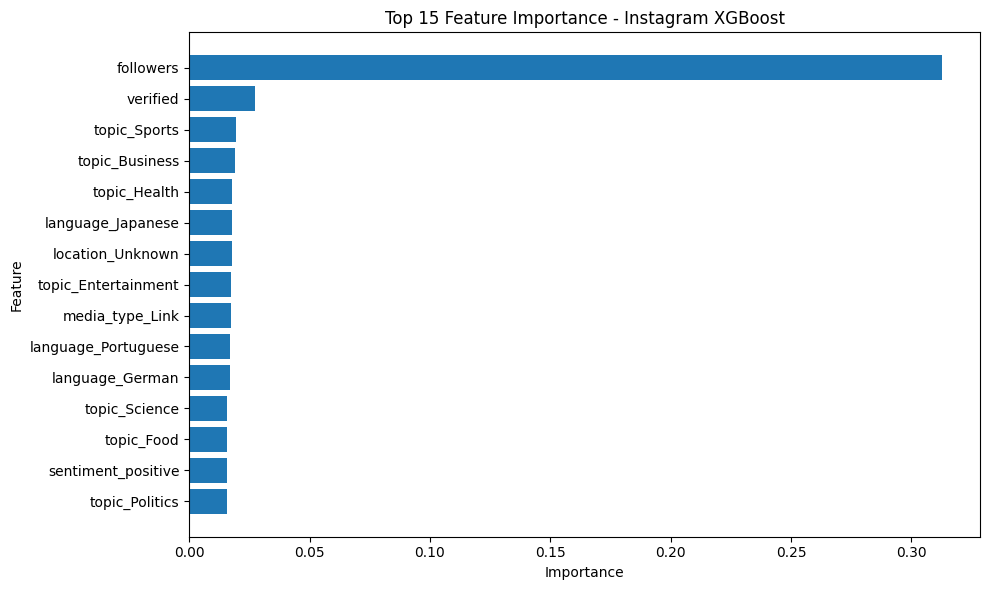

In [13]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Instagram XGBoost"
)

plt.tight_layout()

plt.show()